In [1]:
import os
files = os.listdir(r'C:\Users\pench\Documents\ecommerce-segmentation\data\raw')
for f in files:
    print(f)

flipkart_com-ecommerce_sample.csv
List of Orders.csv
Order Details.csv
Sales target.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

base = r'C:\Users\pench\Documents\ecommerce-segmentation\data\raw'

# load all datasets
orders   = pd.read_csv(f'{base}\\List of Orders.csv')
details  = pd.read_csv(f'{base}\\Order Details.csv')
targets  = pd.read_csv(f'{base}\\Sales target.csv')
flipkart = pd.read_csv(f'{base}\\flipkart_com-ecommerce_sample.csv')

print(" all files loaded!")
print(f"Orders    : {orders.shape}")
print(f"Details   : {details.shape}")
print(f"Targets   : {targets.shape}")
print(f"Flipkart  : {flipkart.shape}")


 all files loaded!
Orders    : (560, 5)
Details   : (1500, 6)
Targets   : (36, 3)
Flipkart  : (20000, 15)


In [5]:
# explore order table

print("=== ORDERS TABLE ===")
print(orders.head())
print("\nColumns:", orders.columns.tolist())
print("\nMisssing values:")
print(orders.isnull().sum())

=== ORDERS TABLE ===
  Order ID  Order Date CustomerName           State       City
0  B-25601  01-04-2018       Bharat         Gujarat  Ahmedabad
1  B-25602  01-04-2018        Pearl     Maharashtra       Pune
2  B-25603  03-04-2018        Jahan  Madhya Pradesh     Bhopal
3  B-25604  03-04-2018       Divsha       Rajasthan     Jaipur
4  B-25605  05-04-2018      Kasheen     West Bengal    Kolkata

Columns: ['Order ID', 'Order Date', 'CustomerName', 'State', 'City']

Misssing values:
Order ID        60
Order Date      60
CustomerName    60
State           60
City            60
dtype: int64


In [6]:
# explore order detail table

print("=== ORDER DETAIL TABLE ===")
print(details.head())
print("\nColumns:", details.columns.tolist())
print("\nMissing values:")
print(details.isnull().sum())

=== ORDER DETAIL TABLE ===
  Order ID  Amount  Profit  Quantity     Category      Sub-Category
0  B-25601  1275.0 -1148.0         7    Furniture         Bookcases
1  B-25601    66.0   -12.0         5     Clothing             Stole
2  B-25601     8.0    -2.0         3     Clothing       Hankerchief
3  B-25601    80.0   -56.0         4  Electronics  Electronic Games
4  B-25602   168.0  -111.0         2  Electronics            Phones

Columns: ['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']

Missing values:
Order ID        0
Amount          0
Profit          0
Quantity        0
Category        0
Sub-Category    0
dtype: int64


In [8]:
# explore flipkart table

print("=== FLIPKART TABLE ===")
print(flipkart.head(3))
print("\nColumns:", flipkart.columns.tolist())
print(f"\nTotal products: {len(flipkart):,}")

=== FLIPKART TABLE ===
                            uniq_id            crawl_timestamp  \
0  c2d766ca982eca8304150849735ffef9  2016-03-25 22:59:23 +0000   
1  7f7036a6d550aaa89d34c77bd39a5e48  2016-03-25 22:59:23 +0000   
2  f449ec65dcbc041b6ae5e6a32717d01b  2016-03-25 22:59:23 +0000   

                                         product_url  \
0  http://www.flipkart.com/alisha-solid-women-s-c...   
1  http://www.flipkart.com/fabhomedecor-fabric-do...   
2  http://www.flipkart.com/aw-bellies/p/itmeh4grg...   

                          product_name  \
0  Alisha Solid Women's Cycling Shorts   
1  FabHomeDecor Fabric Double Sofa Bed   
2                           AW Bellies   

                               product_category_tree               pid  \
0  ["Clothing >> Women's Clothing >> Lingerie, Sl...  SRTEH2FF9KEDEFGF   
1  ["Furniture >> Living Room Furniture >> Sofa B...  SBEEH3QGU7MFYJFY   
2  ["Footwear >> Women's Footwear >> Ballerinas >...  SHOEH4GRSUBJGZXE   

   retail_price  disc

In [9]:
# Join on Order ID
df = pd.merge(orders, details, on='Order ID', how='inner')

print(" Tables merged!")
print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

 Tables merged!
Shape: (1500, 10)

Columns: ['Order ID', 'Order Date', 'CustomerName', 'State', 'City', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category']


,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category
0,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,1275.0,-1148.0,7,Furniture,Bookcases
1,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,66.0,-12.0,5,Clothing,Stole
2,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,8.0,-2.0,3,Clothing,Hankerchief
3,B-25601,01-04-2018,Bharat,Gujarat,Ahmedabad,80.0,-56.0,4,Electronics,Electronic Games
4,B-25602,01-04-2018,Pearl,Maharashtra,Pune,168.0,-111.0,2,Electronics,Phones


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

print("Date range:")
print(f"Earliest order : {df['Order Date'].min()}")
print(f"Latest order   : {df['Order Date'].max()}")
print(f"\nTotal unique customers : {df['CustomerName'].nunique()}")
print(f"Total unique orders    : {df['Order ID'].nunique()}")
print(f"Total categories       : {df['Category'].unique()}")

Date range:
Earliest order : 2018-04-01 00:00:00
Latest order   : 2019-03-31 00:00:00

Total unique customers : 332
Total unique orders    : 500
Total categories       : <StringArray>
['Furniture', 'Clothing', 'Electronics']
Length: 3, dtype: str


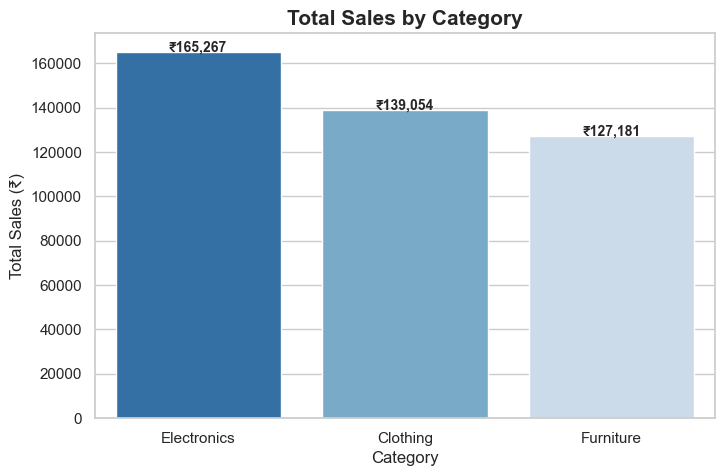

 Plot saved!


In [11]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
bars = sns.barplot(x=category_sales.index, y=category_sales.values,
                   hue=category_sales.index, palette='Blues_r', legend=False)
for bar, val in zip(bars.patches, category_sales.values):
    bars.text(bar.get_x() + bar.get_width()/2,
              bar.get_height() + 100,
              f'₹{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.title('Total Sales by Category', fontsize=15, fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Total Sales (₹)')
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\01_sales_by_category.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

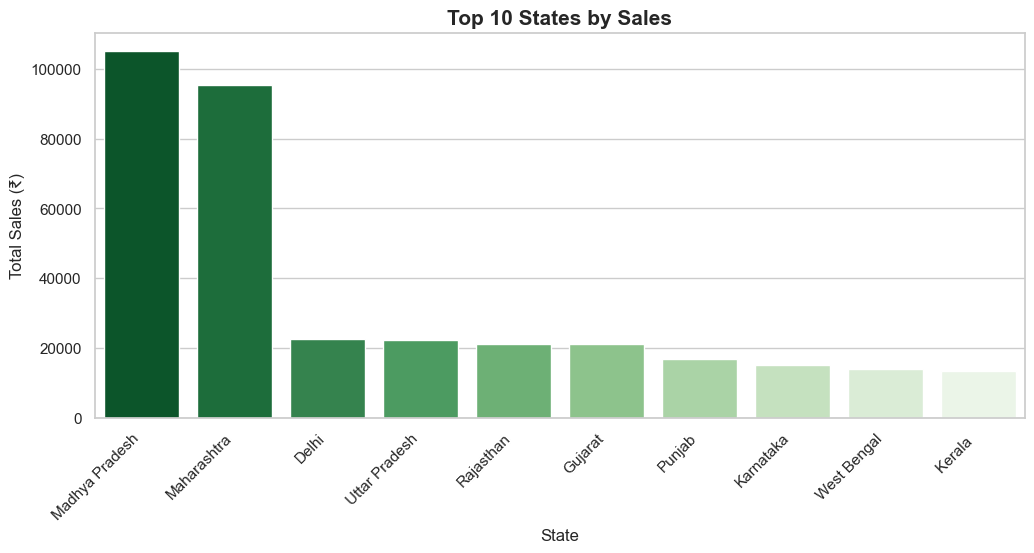

 Plot saved!


In [12]:
state_sales = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))
sns.barplot(x=state_sales.index, y=state_sales.values,
            hue=state_sales.index, palette='Greens_r', legend=False)
plt.title('Top 10 States by Sales', fontsize=15, fontweight='bold')
plt.xlabel('State')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45, ha='right')
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\02_sales_by_state.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

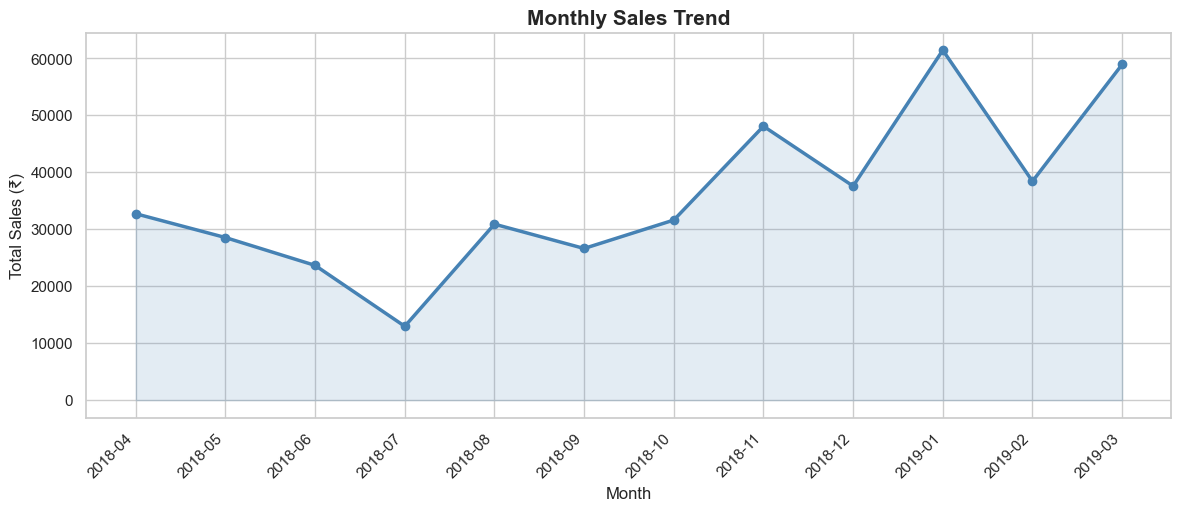

 Plot saved!


In [13]:
df['Month-Year'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('Month-Year')['Amount'].sum()

plt.figure(figsize=(14,5))
plt.plot(monthly_sales.index.astype(str), monthly_sales.values,
         marker='o', color='steelblue', linewidth=2.5)
plt.fill_between(monthly_sales.index.astype(str),
                 monthly_sales.values, alpha=0.15, color='steelblue')
plt.title('Monthly Sales Trend', fontsize=15, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales (₹)')
plt.xticks(rotation=45, ha='right')
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\03_monthly_trend.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")

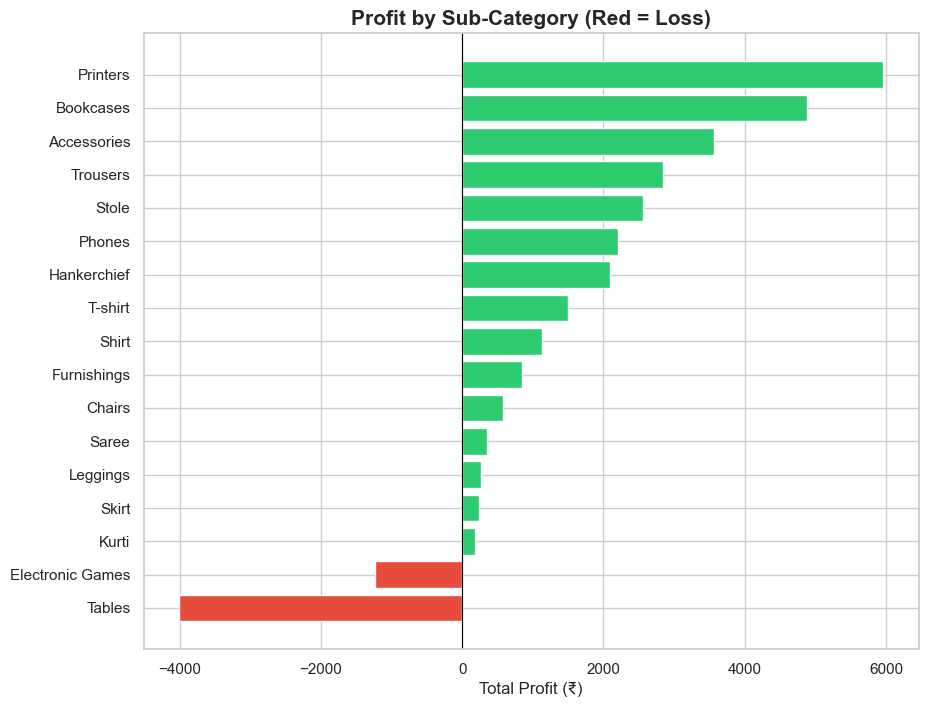

 Plot saved!


In [14]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=True)

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in sub_profit.values]

plt.figure(figsize=(10,8))
plt.barh(sub_profit.index, sub_profit.values, color=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Profit by Sub-Category (Red = Loss)', fontsize=15, fontweight='bold')
plt.xlabel('Total Profit (₹)')
plt.savefig(r'C:\Users\pench\Documents\ecommerce-segmentation\outputs\04_profit_subcategory.png',
            bbox_inches='tight')
plt.show()
print(" Plot saved!")